# 06 — Customer Segmentation (Business Analytics)

**Tujuan notebook ini (Fase 6 roadmap):**
- Bangun feature level customer (Frequency, Monetary, Recency, AOV, Customer Lifetime)
- Segmentasi pakai K-Means
- Penamaan segmen berbasis perilaku (High/Medium/Low Value), BUKAN label "At Risk"/"Champions" tanpa dasar data churn

> ⚠️ **Ini jalur Business Analytics (Fase 6.1), pakai `customer_analytics_full`.** Segmentasi di notebook ini **TIDAK BOLEH** dipakai langsung sebagai ML feature — kalau nanti segmentation dibutuhkan sebagai feature ML, harus dibangun ulang dari `customer_features_observation` di notebook `07_ml_dataset_design.ipynb` (dipotong sampai observation cutoff), bukan dari sini.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

DATA_DIR = Path("../data_processed")
customer_analytics_full = pd.read_csv(
    DATA_DIR / "customer_analytics.csv",
    parse_dates=["first_order_date", "last_order_date"]
)

print("customer_analytics_full shape:", customer_analytics_full.shape)
customer_analytics_full.head()


customer_analytics_full shape: (96096, 8)


,customer_unique_id,total_orders,total_spending,avg_order_value,first_order_date,last_order_date,customer_lifetime_days,customer_state
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27,0,SP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27,0,SP
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,0,SC
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,0,PA
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42,0,SP


---
## Bangun Feature RFM-style

- **Recency** — hari sejak `last_order_date` sampai titik referensi (di sini: tanggal transaksi terakhir di seluruh dataset, karena ini versi full-history untuk business reporting)
- **Frequency** — `total_orders`
- **Monetary** — `total_spending`
- **AOV** — `avg_order_value`
- **Customer Lifetime** — `customer_lifetime_days`


In [2]:
reference_date = customer_analytics_full["last_order_date"].max()
print(f"Reference date (tanggal transaksi terakhir di dataset): {reference_date}")

rfm = customer_analytics_full.copy()
rfm["recency_days"] = (reference_date - rfm["last_order_date"]).dt.days

feature_cols = ["recency_days", "total_orders", "total_spending", "avg_order_value", "customer_lifetime_days"]
rfm_features = rfm[feature_cols].fillna(0)  # customer_lifetime_days = 0 untuk yang cuma 1x order, ini VALID (bukan missing delivery case)

print("Statistik feature sebelum scaling:")
rfm_features.describe()


Reference date (tanggal transaksi terakhir di dataset): 2018-10-17 17:30:18
Statistik feature sebelum scaling:


,recency_days,total_orders,total_spending,avg_order_value,customer_lifetime_days
count,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000
mean,287.735691,1.034809,166.592492,161.400116,2.711507
std,153.414676,0.214384,231.428332,222.307531,25.393343
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,163.000000,1.000000,63.120000,62.457500,0.000000
50%,268.000000,1.000000,108.000000,105.825000,0.000000
75%,397.000000,1.000000,183.530000,177.210000,0.000000
max,772.000000,17.000000,13664.080000,13664.080000,633.000000


---
## K-Means Clustering

Scaling dulu (K-Means sensitif terhadap skala), lalu cari jumlah cluster yang masuk akal (elbow method), baru fit final.


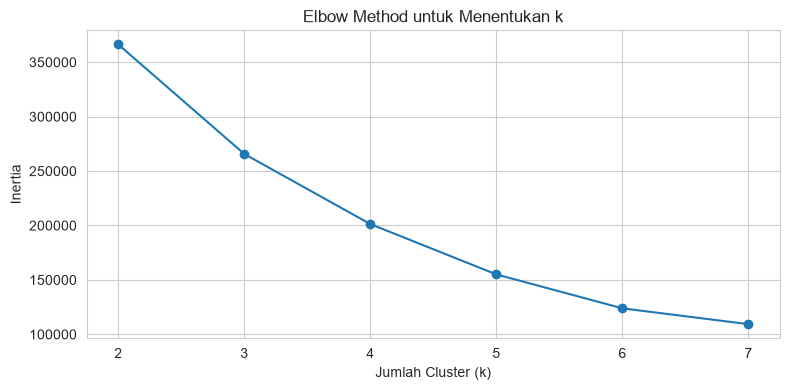

In [3]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Elbow method untuk cek jumlah cluster yang masuk akal
inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), inertias, marker="o")
ax.set_xlabel("Jumlah Cluster (k)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method untuk Menentukan k")
plt.tight_layout()
plt.show()


In [4]:
# Pakai k=3 untuk MVP (High/Medium/Low Value) - sesuaikan kalau elbow chart menyarankan lain
K_FINAL = 3

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

print(f"Distribusi customer per cluster (k={K_FINAL}):")
print(rfm["cluster"].value_counts().sort_index())

print("\nRata-rata feature per cluster (untuk interpretasi):")
cluster_summary = rfm.groupby("cluster")[feature_cols].mean()
print(cluster_summary)


Distribusi customer per cluster (k=3):
cluster
0    91460
1     1318
2     3318
Name: count, dtype: int64

Rata-rata feature per cluster (untuk interpretasi):
         recency_days  total_orders  total_spending  avg_order_value  \
cluster                                                                
0          288.417789      1.017275      132.298462       130.242761   
1          219.779211      2.261760      319.900326       141.589712   
2          295.927969      1.030741     1051.002444      1028.154793   

         customer_lifetime_days  
cluster                          
0                      0.194621  
1                    183.107739  
2                      0.430681  


---
## Penamaan Segmen — Berbasis Perilaku (BUKAN "At Risk"/"Champions")

Urutkan cluster berdasarkan `total_spending` rata-rata, beri label **High/Medium/Low Value** — bukan label churn-related yang tidak punya dasar data eksplisit di dataset ini.


In [5]:
# Urutkan cluster berdasarkan avg total_spending (descending), assign label
cluster_order = cluster_summary["total_spending"].sort_values(ascending=False).index
label_map = {
    cluster_order[0]: "High Value",
    cluster_order[1]: "Medium Value",
    cluster_order[2]: "Low Value",
}
rfm["segment"] = rfm["cluster"].map(label_map)

print("Distribusi customer per segment:")
print(rfm["segment"].value_counts())

print("\nRata-rata feature per segment:")
print(rfm.groupby("segment")[feature_cols].mean().reindex(["High Value", "Medium Value", "Low Value"]))


Distribusi customer per segment:
segment
Low Value       91460
High Value       3318
Medium Value     1318
Name: count, dtype: int64

Rata-rata feature per segment:
              recency_days  total_orders  total_spending  avg_order_value  \
segment                                                                     
High Value      295.927969      1.030741     1051.002444      1028.154793   
Medium Value    219.779211      2.261760      319.900326       141.589712   
Low Value       288.417789      1.017275      132.298462       130.242761   

              customer_lifetime_days  
segment                               
High Value                  0.430681  
Medium Value              183.107739  
Low Value                   0.194621  


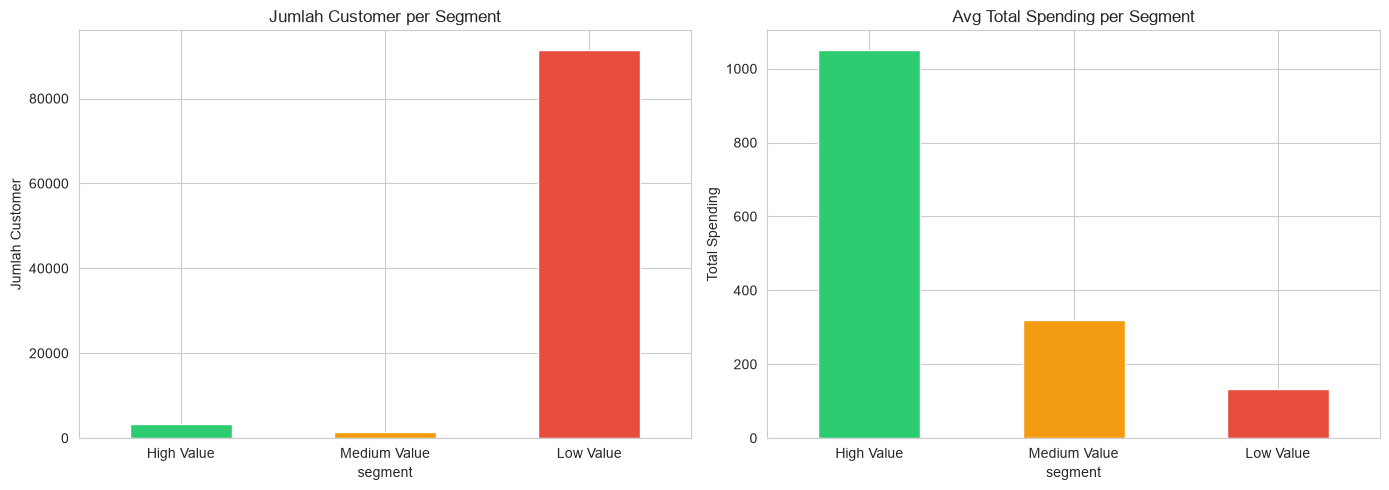

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_order = ["High Value", "Medium Value", "Low Value"]
rfm["segment"].value_counts().reindex(segment_order).plot(kind="bar", ax=axes[0], color=["#2ecc71", "#f39c12", "#e74c3c"])
axes[0].set_title("Jumlah Customer per Segment")
axes[0].set_ylabel("Jumlah Customer")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0)

rfm.groupby("segment")["total_spending"].mean().reindex(segment_order).plot(kind="bar", ax=axes[1], color=["#2ecc71", "#f39c12", "#e74c3c"])
axes[1].set_title("Avg Total Spending per Segment")
axes[1].set_ylabel("Total Spending")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.show()


> **Catatan penting:** label "High/Medium/Low Value" ini murni deskriptif berdasarkan cluster spending — bukan prediksi perilaku masa depan. Kalau nanti mau naik level ke label seperti "At Risk", perlu threshold eksplisit berbasis `recency_days` yang dikombinasikan dengan penurunan frekuensi dibanding baseline historis customer tersebut — bukan sekadar hasil cluster mentah.


---
## Simpan Hasil Segmentasi

Disimpan sebagai tabel terpisah untuk dipakai di Power BI (Fase 12, Dashboard 2 — Customer Analytics).


In [7]:
segmentation_output = rfm[[
    "customer_unique_id", "recency_days", "total_orders", "total_spending",
    "avg_order_value", "customer_lifetime_days", "segment"
]]

segmentation_output.to_csv(DATA_DIR / "customer_segmentation_full.csv", index=False)
print(f"Tersimpan: {DATA_DIR / 'customer_segmentation_full.csv'}")
print(f"Shape: {segmentation_output.shape}")


Tersimpan: ..\data_processed\customer_segmentation_full.csv
Shape: (96096, 7)


---
## Definition of Done (Fase 6)

- [ ] Feature RFM-style dibangun dari `customer_analytics_full` (full-history, business analytics)
- [ ] K-Means clustering dijalankan dengan justifikasi jumlah cluster (elbow method)
- [ ] Segmen diberi label berbasis perilaku (High/Medium/Low Value), BUKAN "At Risk"/"Champions" tanpa dasar
- [ ] Hasil segmentasi tersimpan untuk Power BI
- [ ] Paham bahwa segmentasi ini TIDAK dipakai langsung sebagai ML feature (lihat Fase 6.1)

**Lanjut ke:** `07_ml_dataset_design.ipynb` — di sini mulai masuk **Decision Gate**: distribusi tanggal aktual, observation/prediction window final, dan cek ulang positive case sebelum target ML dikunci.
